# Import library

In [1]:
import rasterio
import torchgeo
import torch
import torch.nn as nn
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
# import pycuda.driver as cuda

# Set seed to make it reproducible

In [2]:
# Set seeds for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# Import data

## Sentinel-2 image

In [3]:
sentinel2_path = '../data/raw/sentinel-2/sentinel2_openeo_med_4months_dresden.geotiff'
data = rioxarray.open_rasterio(sentinel2_path)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

In [4]:
data.band

<xarray.DataArray 'band' (band: 13)> Size: 104B
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
    spatial_ref  int64 8B 0

In [5]:
data.sel(band=1).dtype

dtype('int16')

Min and max normalization give the worst result according to https://medium.com/sentinel-hub/how-to-normalize-satellite-images-for-deep-learning-d5b668c885af

In [6]:
# Normalize the bands to the range [0, 1]
def normalize(array):
    array_min, array_max = array.min(), array.max()
    return (array - array_min) / (array_max - array_min)

In [7]:
# 2th percentile to 98th percentile
# Apply a percentile-based contrast stretch (ignore the extreme values so image isn't too dark or too bright)
def contrast_stretch(array, lower_percentile=2, upper_percentile=98):
    lower = np.percentile(array, lower_percentile)
    upper = np.percentile(array, upper_percentile)
    array = np.clip(array, lower, upper) # clip -> limit the values in an array to specific range
    return (array - lower) / (upper - lower) # normalization

In [8]:
# 1th percentile to 99th percentile
# Apply a percentile-based contrast stretch (ignore the extreme values so image isn't too dark or too bright)
def contrast_stretch_new(array, lower_percentile=1, upper_percentile=99):
    lower = np.percentile(array, lower_percentile)
    upper = np.percentile(array, upper_percentile)
    print('lower: ', lower)
    print('upper: ', upper)
    array = np.clip(array, lower, upper) # clip -> limit the values in an array to specific range
    return (array - lower) / (upper - lower) # normalization

lower:  4.0
upper:  4145.0


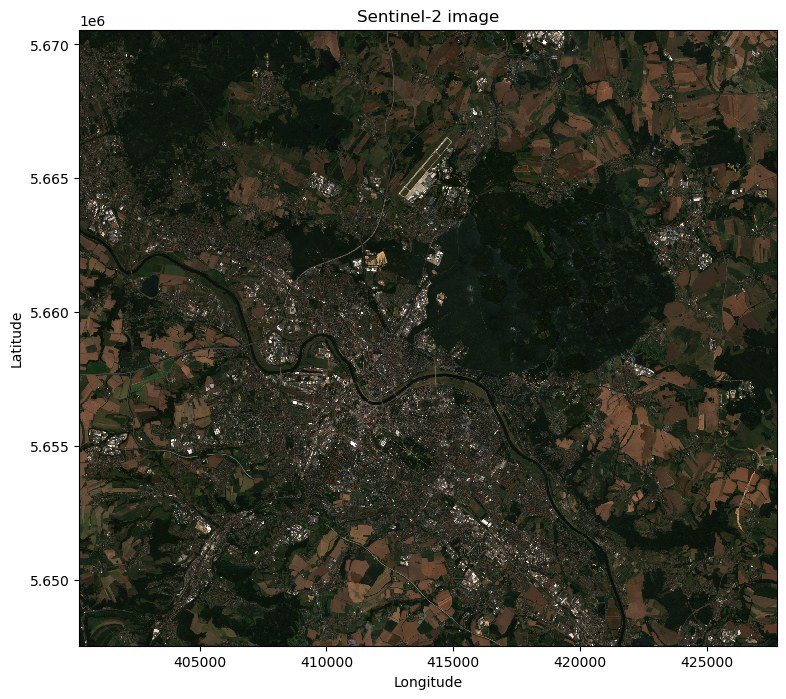

In [9]:
# Plot the raster data
plt.figure(figsize=(9,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
contrast_stretch_new(data).sel(band=[4, 3, 2]).plot.imshow()
plt.title("Sentinel-2 image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Binary mask

In [10]:
mask_path = '../data/processed/osm/public_green_spaces_dresden.geotiff'
mask_data = rioxarray.open_rasterio(mask_path)

In [11]:
mask_data = mask_data.astype('float32')

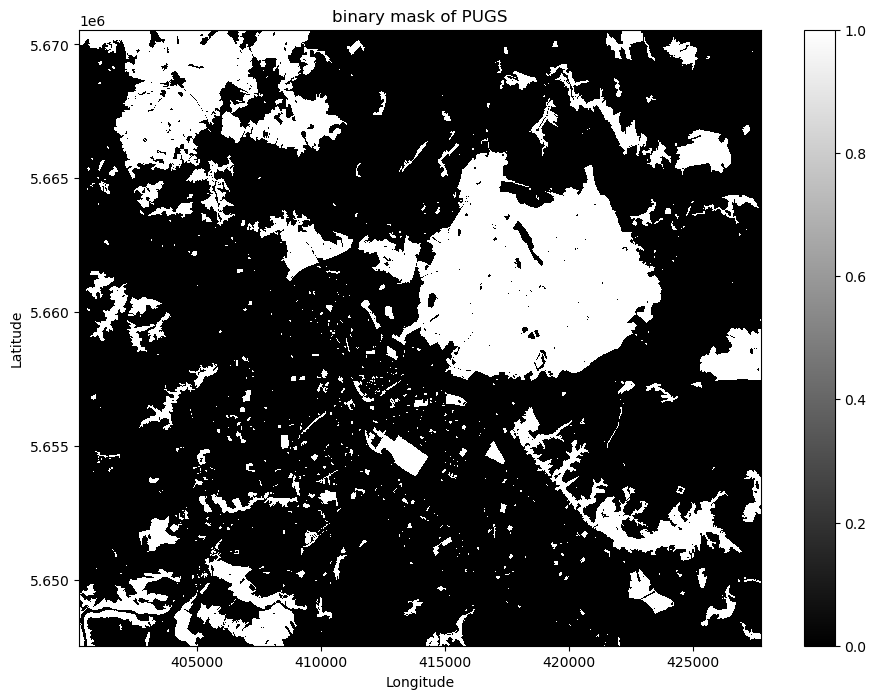

In [12]:
# Plot the raster data
plt.figure(figsize=(11,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
mask_data.sel(band=1).plot.imshow(cmap='gray')
plt.title("binary mask of PUGS")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## NDVI raster

In [13]:
ndvi_path = '../data/raw/sentinel-2/ndvi_sentinel2_openeo_med_4months_dresden.geotiff'
ndvi_data = rioxarray.open_rasterio(ndvi_path)

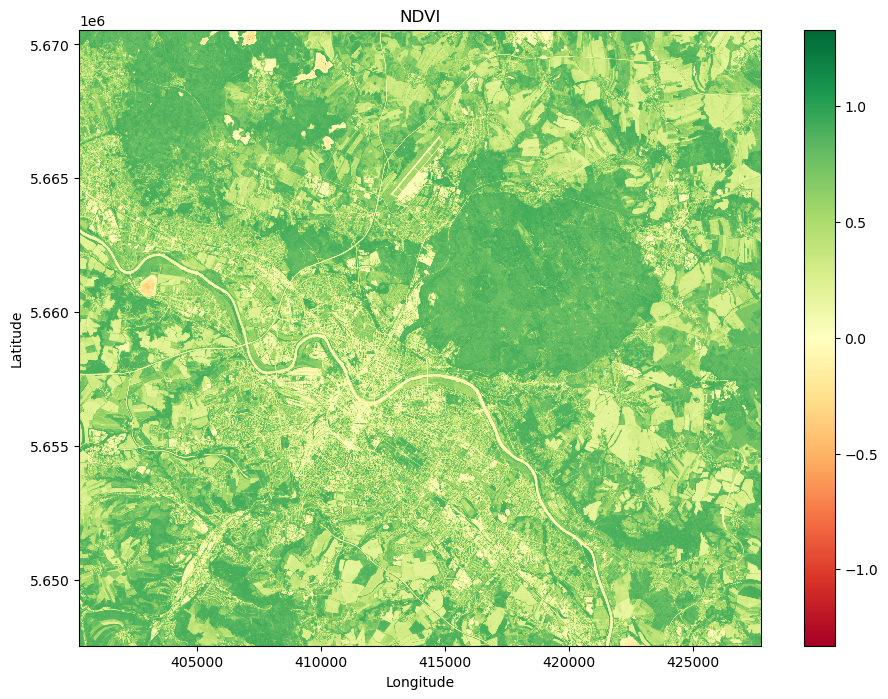

In [14]:
# Plot the raster data
plt.figure(figsize=(11,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
ndvi_data.sel(band=1).plot.imshow(cmap='RdYlGn')
plt.title("NDVI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## NDWI raster

In [15]:
ndwi_path = '../data/raw/sentinel-2/ndwi_sentinel2_openeo_med_4months_dresden.geotiff'
ndwi_data = rioxarray.open_rasterio(ndwi_path)

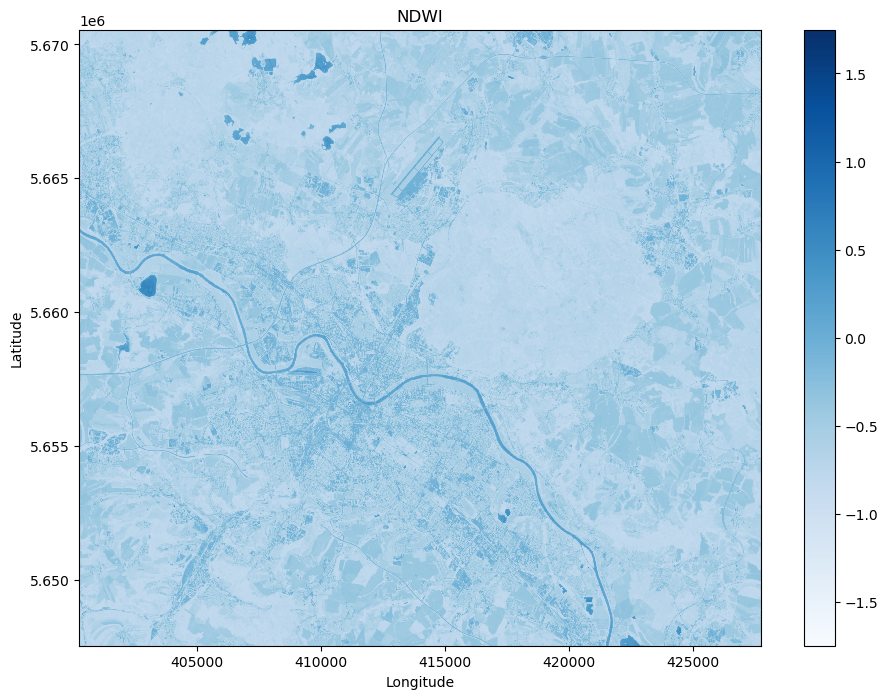

In [16]:
# Plot the raster data
plt.figure(figsize=(11,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
ndwi_data.sel(band=1).plot.imshow(cmap='Blues')
plt.title("NDWI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# NDBI raster

In [17]:
ndbi_path = '../data/raw/sentinel-2/ndbi_sentinel2_openeo_med_4months_dresden.geotiff'
ndbi_data = rioxarray.open_rasterio(ndbi_path)

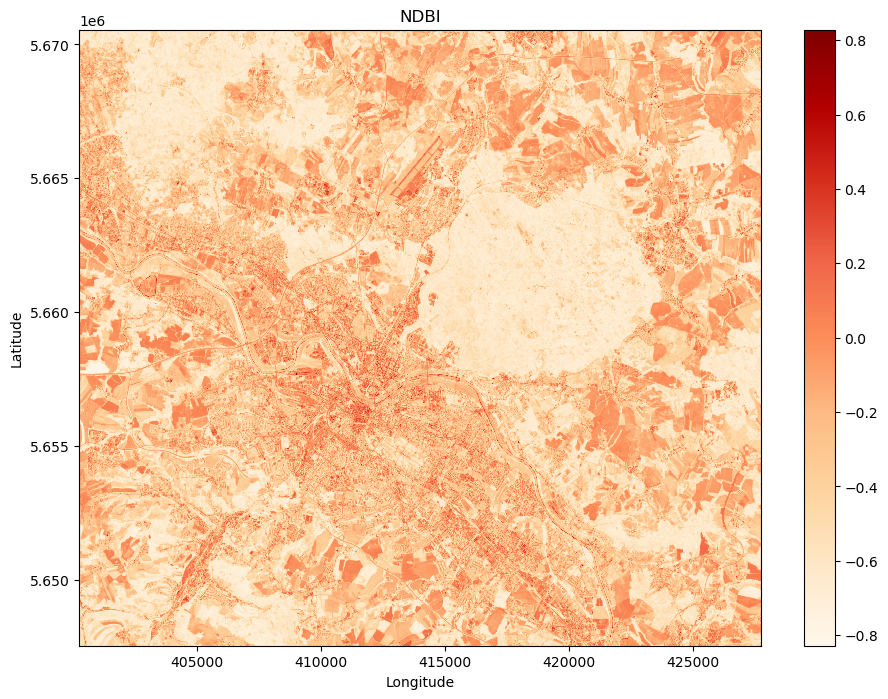

In [18]:
# Plot the raster data
plt.figure(figsize=(11,8))
# normalize(data).sel(band=[4, 3, 2]).plot.imshow()
ndbi_data.sel(band=1).plot.imshow(cmap='OrRd')
plt.title("NDBI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Create image patches (Torchgeo)

## Create ROI for training, validation, and test set

manually specify

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

lower:  4.0
upper:  4145.0


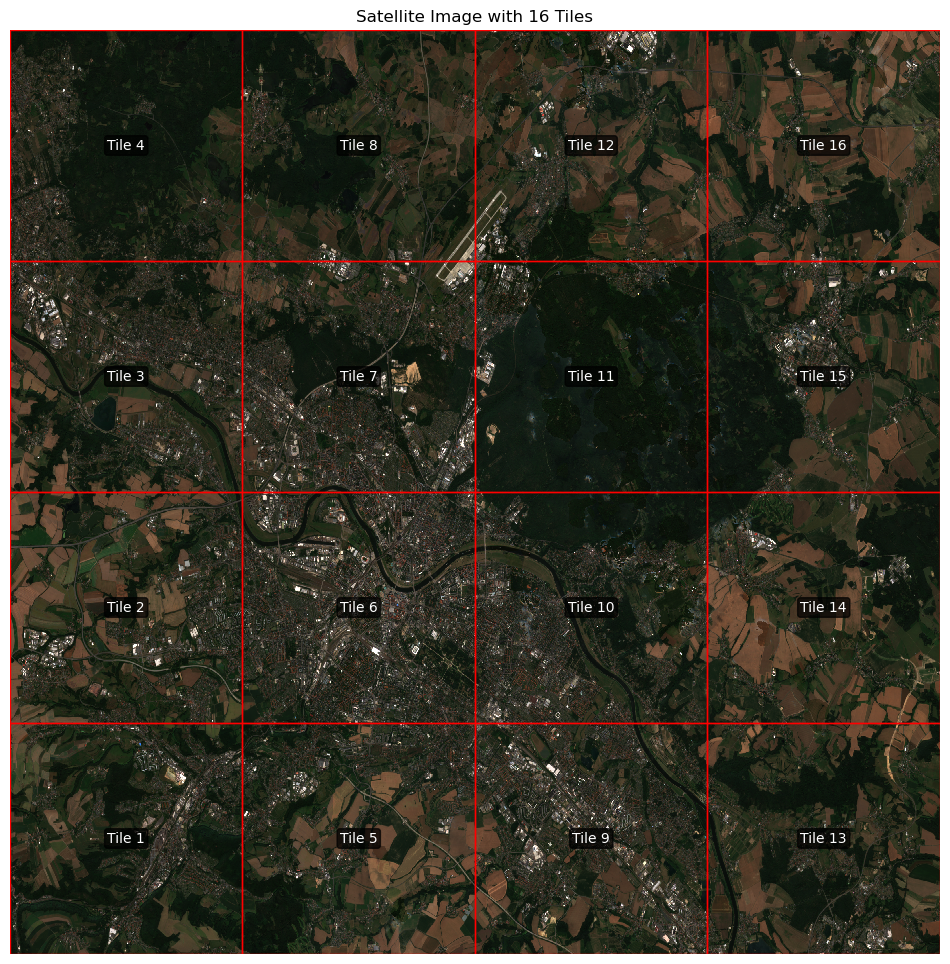

In [19]:
import matplotlib.patches as patches
import os

# Create a folder for saving the tiles
folder_path = '../data/processed/tiles'
os.makedirs(folder_path, exist_ok=True)

# Open the raster data
rds = rioxarray.open_rasterio(sentinel2_path)

rds_sample = rds.isel(band=0)

# Get the bounds of the image
xmin, ymin, xmax, ymax = rds.rio.bounds()

# Calculate the width and height of each tile
tile_width = (xmax - xmin) / 4
tile_height = (ymax - ymin) / 4

# Create 16 tiles (4x4 grid)
tiles = []
for i in range(4):
    for j in range(4):
        tile_xmin = xmin + i * tile_width
        tile_xmax = tile_xmin + tile_width
        tile_ymin = ymin + j * tile_height
        tile_ymax = tile_ymin + tile_height
        tiles.append([tile_xmin, tile_xmax, tile_ymin, tile_ymax])

# Plot the original satellite image with bounding boxes for the 16 tiles
plt.figure(figsize=(12, 12))
contrast_stretch_new(data).sel(band=[4, 3, 2]).plot.imshow()
plt.axis('off')

# Add bounding boxes for each tile
ax = plt.gca()
for idx, tile in enumerate(tiles):
    tile_xmin, tile_xmax, tile_ymin, tile_ymax = tile
    width = tile_xmax - tile_xmin
    height = tile_ymax - tile_ymin
    
    # Create a rectangle patch
    rect = patches.Rectangle((tile_xmin, tile_ymin), width, height, 
                            linewidth=1, edgecolor='r', facecolor='none')
    
    # Add the rectangle to the plot
    ax.add_patch(rect)
    
    # Add text label for the tile number
    plt.text(tile_xmin + width/2, tile_ymin + height/2, f'Tile {idx+1}', 
             ha='center', va='center', color='white', fontsize=10,
             bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.2'))

    # Clip the raster to this tile and save it
    if(not(os.path.exists(folder_path))):
        tile_rds = rds.rio.clip_box(minx=tile_xmin, miny=tile_ymin, maxx=tile_xmax, maxy=tile_ymax)
        tile_file_path = os.path.join(folder_path, f'tile_{idx + 1}.tif')
        tile_rds.rio.to_raster(tile_file_path)
        print(f"Tile {idx + 1} saved to {tile_file_path}")

plt.title('Satellite Image with 16 Tiles')
# plt.savefig('satellite_image_with_tiles.png', dpi=300)
plt.show()

---

In [20]:
from torchgeo.datasets import RasterDataset, VectorDataset, unbind_samples, stack_samples, Sentinel2
from pyproj import CRS

train_path = '../data/processed/tiles/train'
train_ds = RasterDataset(paths=folder_path, crs=CRS.from_epsg(32633), res=10)

In [21]:
train_ds.bounds

BoundingBox(minx=400260.0, maxx=427730.0, miny=5647540.0, maxy=5670550.0, mint=0.0, maxt=9.223372036854776e+18)

In [22]:
train_label = VectorDataset(paths='../data/processed/osm/public_green_spaces_dresden.geojson', crs=CRS.from_epsg(32633), res=10)

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


In [23]:
new_train_ds = train_ds & train_label

In [ ]:
from torchgeo.samplers import RandomGeoSampler

# with RandomGeoSampler -> it won't be reproducible
torch.manual_seed(seed)
sampler = RandomGeoSampler(new_train_ds, size=(256, 256), length=100)

lower:  4.0
upper:  4119.0


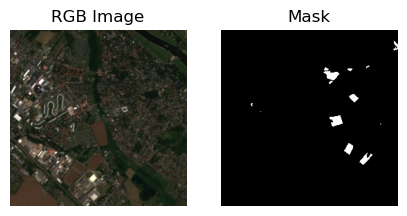

lower:  4.0
upper:  4089.0


/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


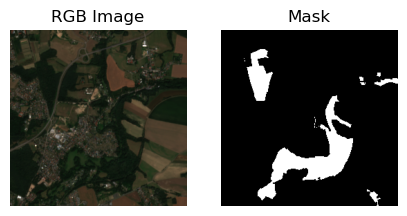

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


lower:  4.0
upper:  3807.0


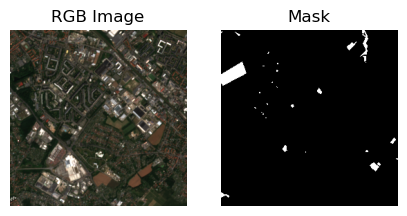

lower:  4.0
upper:  4100.0


/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


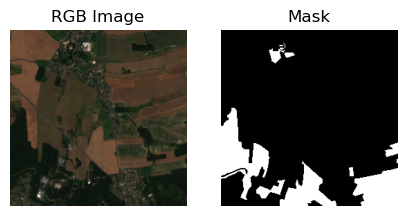

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


lower:  4.0
upper:  3752.329999999958


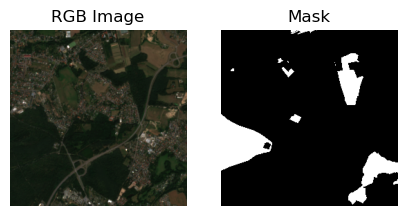

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


lower:  4.0
upper:  4071.0


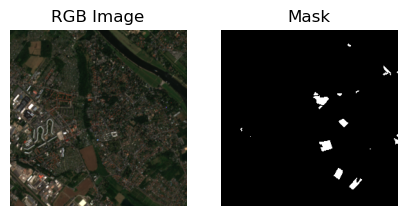

In [ ]:
torch.manual_seed(seed)
for i, bbox in enumerate(sampler):
    sample = new_train_ds[bbox]

    arr = contrast_stretch_new(sample['image']).numpy()
    mask = sample['mask'].numpy()

    # Transpose the array to get the correct shape for RGB (height, width, channels)
    rgb = arr.transpose(1, 2, 0)[:, :, [3, 2, 1]]

    fig, ax = plt.subplots(1, 2, figsize=(5, 5))
    
    # Display the RGB image in the first subplot
    ax[0].imshow(rgb)
    ax[0].set_title('RGB Image')
    ax[0].axis('off')

    # Display the mask in the second subplot
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title('Mask')
    ax[1].axis('off')

    plt.show()
    
    if i == 5:
        break

---

In [25]:
# bbox = next(iter(sampler))
# sample = new_train_ds[bbox]
# print(sample.keys())
# print(sample['image'].shape)
# print(sample['mask'].shape)

In [26]:
# arr = contrast_stretch_new(sample['image']).numpy()
# mask = sample['mask'].numpy()

# # Print the shape of the image array
# print(arr.shape)

# # Transpose the array to get the correct shape for RGB (height, width, channels)
# rgb = arr.transpose(1, 2, 0)[:, :, [3, 2, 1]]

# # Create a figure with two subplots
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# # Display the RGB image in the first subplot
# axes[0].imshow(rgb)
# axes[0].set_title('RGB Image')
# axes[0].axis('off')

# # Display the mask in the second subplot
# axes[1].imshow(mask, cmap='gray')
# axes[1].set_title('Mask')
# axes[1].axis('off')

# # Show the figure
# plt.show()

In [28]:
from torchgeo.datasets import RasterDataset, VectorDataset, unbind_samples, stack_samples, Sentinel2
from pyproj import CRS

train_ds = RasterDataset(paths=sentinel2_path, crs=CRS.from_epsg(32633), res=10)

In [29]:
train_ds.bounds

BoundingBox(minx=400260.0, maxx=427730.0, miny=5647540.0, maxy=5670550.0, mint=0.0, maxt=9.223372036854776e+18)

In [30]:
from torchgeo.datasets.utils import BoundingBox

train_bounds = BoundingBox(*roi_1, mint=0, maxt=1)
test_bounds = BoundingBox(*roi_2, mint=0, maxt=1)

NameError: name 'roi_1' is not defined

In [ ]:
from torchgeo.samplers import RandomGeoSampler

sampler = RandomGeoSampler(train_ds, size=(256, 256), roi=train_bounds, length=100)

In [ ]:
import torch

torch.manual_seed(0) # this is to get the same result in every pass
bbox = next(iter(sampler))
print(bbox)
sample = train_ds[bbox]
print(sample.keys())
print(sample['image'].shape)

BoundingBox(minx=401240.0, maxx=403800.0, miny=5650240.0, maxy=5652800.0, mint=0.0, maxt=1.0)
dict_keys(['crs', 'bounds', 'image'])
torch.Size([13, 256, 256])


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

lower:  4.0
upper:  4266.0
(13, 256, 256)


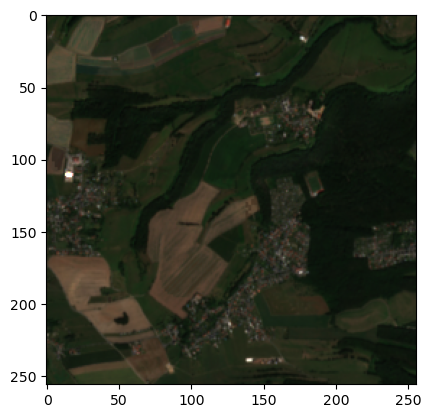

In [ ]:
import torch
import matplotlib.pyplot as plt

# arr = torch.clamp(sample['image']/10000, min=0, max=1).numpy()
arr = contrast_stretch_new(sample['image']).numpy()
# arr = torch.from_numpy(arr)
print(arr.shape)
# Transpose the array to get the correct shape for RGB (height, width, channels)
rgb = arr.transpose(1, 2, 0)[:, :, [3, 2 , 1]]

plt.imshow(rgb)

In [ ]:
train_label = VectorDataset(paths='../data/processed/osm/public_green_spaces_dresden.geojson', crs=CRS.from_epsg(32633), res=10)

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


In [ ]:
new_train_ds = train_ds & train_label

In [ ]:
from torchgeo.samplers import RandomGeoSampler
sampler = RandomGeoSampler(new_train_ds, size=(256, 256), roi=test_bounds, length=100)

In [ ]:
torch.manual_seed(0)
bbox = next(iter(sampler))
sample = new_train_ds[bbox]
print(sample.keys())
print(sample['image'].shape)
print(sample['mask'].shape)

dict_keys(['crs', 'bounds', 'image', 'mask'])
torch.Size([13, 256, 256])
torch.Size([256, 256])


lower:  4.0
upper:  3951.0
(13, 256, 256)


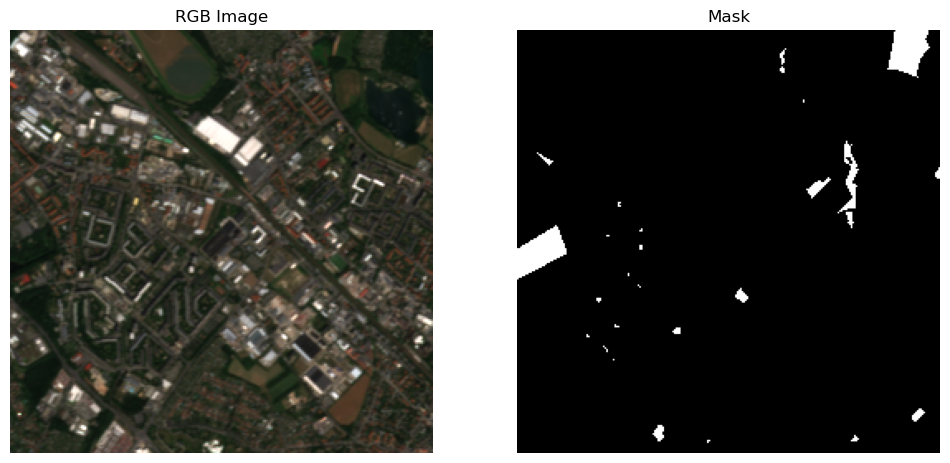

In [ ]:
arr = contrast_stretch_new(sample['image']).numpy()
mask = sample['mask'].numpy()

# Print the shape of the image array
print(arr.shape)

# Transpose the array to get the correct shape for RGB (height, width, channels)
rgb = arr.transpose(1, 2, 0)[:, :, [3, 2, 1]]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the RGB image in the first subplot
axes[0].imshow(rgb)
axes[0].set_title('RGB Image')
axes[0].axis('off')

# Display the mask in the second subplot
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask')
axes[1].axis('off')

# Show the figure
plt.show()

lower:  4.0
upper:  3951.0
(13, 256, 256)


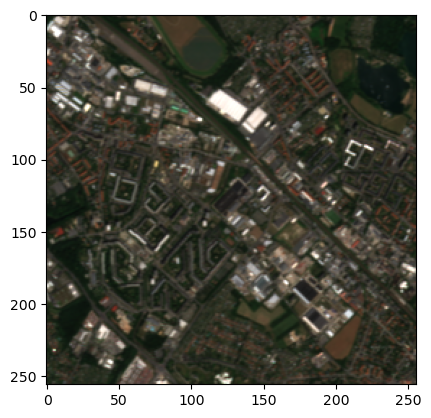

In [ ]:
import torch
import matplotlib.pyplot as plt

# arr = torch.clamp(sample['image']/10000, min=0, max=1).numpy()
arr = contrast_stretch_new(sample['image']).numpy()
# arr = torch.from_numpy(arr)
print(arr.shape)
rgb = arr.transpose(1, 2, 0)[:, :, [3, 2 , 1]]

plt.imshow(rgb)

## Try using torchgeo splitting utility

In [ ]:
from torchgeo.datasets import roi_split

In [ ]:
print(train_bounds)
print(test_bounds)

BoundingBox(minx=400260.0, maxx=413995.0, miny=5647540.0, maxy=5670550.0, mint=0, maxt=1)
BoundingBox(minx=413995.0, maxx=427730.0, miny=5647540.0, maxy=5670550.0, mint=0, maxt=1)


In [ ]:
train_dataset, test_dataset = roi_split(train_ds, [train_bounds, test_bounds]) 

In [ ]:
# train_ds.bounds

In [ ]:
train_dataset